## Geocalibration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import itertools
from tqdm import tqdm
from typing import List
import json

In [13]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# function for parsing data
def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

# Functions for Iterative Kabsch algorithm fits and plots
def solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    scaled_hm = (R_rrp @ R_rpm).T @ hr @ np.diag([lambda_h, lambda_v, lambda_a])
    m_frame.append(list(scaled_hm[:,0]))
    m_frame.append(list(scaled_hm[:,1]))
    m_frame.append(list(scaled_hm[:,2]))

    # compute hm from hc
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
    scaled_hc = hc @ np.diag([lambda_h, lambda_v, lambda_a])
    c_frame.append(scaled_hc[:,0])
    c_frame.append(scaled_hc[:,1])
    c_frame.append(scaled_hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd

def solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    scaled_hr = hr @ np.diag([lambda_h, lambda_v, lambda_a])
    r_frame.append(list(scaled_hr[:,0]))
    r_frame.append(list(scaled_hr[:,1]))
    r_frame.append(list(scaled_hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    scaled_hrp = R_rpm @ R_mc @ hc @ np.diag([lambda_h, lambda_v, lambda_a])
    rp_frame.append(list(scaled_hrp[:,0]))
    rp_frame.append(list(scaled_hrp[:,1]))
    rp_frame.append(list(scaled_hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc):
  # compute the relative error
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

def plot_hr(data_, rot_rrp, rot_mc, fstr):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_res(data_, rot_rrp, rot_mc, fstr):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ fit residuals for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_rel_err(data_, rot_rrp, rot_mc, fstr):
  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    Hr_compute = R_rrp @ R_rpm @ R_mc @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle(f"$H^r$ relative errors for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def kabsch_fit(data_, lambda_h, lambda_v, lambda_a, verbosity, iter=50, verbose=25, epsilon=1e-17):
  """
  Performs the iterative kabsch algorithm to find rot_rrp and rot_mc
  """
  iter, verbose, epsilon = 50, 25, 1e-17

  # here we use the best lambdas to redo the fit and plot the results in Hr space
  rot_rrp_rssd = float('inf')
  rot_rrp = R.from_quat([0, 0, 0, 1])
  for i in range(iter):
    rot_mc, rot_mc_rssd = solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a)
    rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a)

    if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon and verbosity:
      print('-' * 150)
      print(f"Convergence critertia met at {i}")
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
      break

    rot_rrp_rssd = old_rot_rrp_rssd

    if ((i+1) % verbose == 0) and verbosity:
      print('-' * 150)
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
  
  return rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd

def dist_q(q1, q2):
  q1 = np.array(q1)/np.linalg.norm(q1)
  q2 = np.array(q2)/np.linalg.norm(q2)

  return np.linalg.norm(q1-q2)

# Functions for BFGS fits and plots
def gen_obj(data_, q_rrp):
  data__ = data_.copy()
  R_rrp = R.from_quat(q_rrp).as_matrix()

  # objective function to minimize over
  def obj(x:List):
    rot_mc_0 = R.from_quat(x[:4])
    rot_mc_1 = R.from_quat(x[4:8])

    total_cost = 0
    for i in range(data__.shape[0]):
      # H^r matrix
      Hr = get_H_r_data(i, data__)

      # H^c matrix
      fl, b1, b2, cx, cy = data__[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
      Hc = [[fl+b1, 0, 0],
            [b2, fl, 0],
            [cx, cy, 1]]
      

      

      # rotation matrices
      R_rpm = get_R_rpm(i, data__)
      f = data__["fmc"][i]
      R_mc = (rot_mc_0 * (rot_mc_1**(f/1000))).as_matrix()
      

      # Errors
      q_rc_data = R.from_matrix(Hr @ np.linalg.inv(Hc)).as_quat(canonical=True)
      q_rc_model = R.from_matrix(R_rrp @ R_rpm @ R_mc).as_quat(canonical=True)
      total_cost += dist_q(q_rc_data, q_rc_model)

    return total_cost/data_.shape[0]
  
  return obj

def plot_qmc_hr_rel_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_rrp = R.from_quat(q_rrp)
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)

  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hr from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    f = data_["fmc"][i]
    rot_rc = rot_rrp * rot_rpm * (rot_mc_zl_0 * (rot_mc_zl_1**(f/1000)))

    Hr_compute = rot_rc.as_matrix() @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))
    # hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0]))
    # vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1]))
    # ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle("$H^r$ relative errors", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_zl_0 * (rot_mc_zl_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qrc(data, q_rrp, q_mc_0, q_mc_1):
  # compute quaternion for rotations from r to c from data 
  q_rc_model = []
  q_rc_data = []

  rot_rrp = R.from_quat(q_rrp)
  for i in range(data.shape[0]):
    # compute quaternions from data
    H_r = get_H_r_data(i, data)
    fl, b1, b2, cx, cy = data[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = [[fl+b1, 0, 0],
              [b2, fl, 0],
              [cx, cy, 1]]
    rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(Hc))
    q_rc_d = rot_rc_data.as_quat(canonical=True)
    q_rc_data.append(q_rc_d)

    # compute quaternion from model
    f = data["fmc"][i]
    rot_rpm = R.from_matrix(get_R_rpm(i, data))
    rot_mc = R.from_quat(q_mc_0) * (R.from_quat(q_mc_1)**(f/1000))
    rot_rc = rot_rrp * rot_rpm * rot_mc
    q_rc_m = rot_rc.as_quat(canonical=True)
    q_rc_model.append(q_rc_m)

  # plot each of the quaternion
  fig, ax = plt.subplots(1,4, figsize=(16,4))

  for i in range(4):
    ax[i].scatter(data["fmc"], [q[i] for q in q_rc_data], label="data")
    ax[i].scatter(data["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
    ax[i].set_title(f"$q^r_c$[{i}]")

  ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
  fig.suptitle("Rotation r to c", fontsize=16, fontweight="bold")
  fig.tight_layout()

In [14]:
data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)

### Hyperparameter Tuning

Here we find the best scaling hyperparameters across all focuses 




In [15]:
# q_rrp_0 = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
# iter, verbose = 50, 25

# # search space 
# f_strs = ["026", "034", "048", "063", "079", "100", "110"]
# lambda_hs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
# lambda_vs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
# lambda_as = [0.3, 0.9, 3, 9, 30, 90]


# hyper_params = {f"ZL{f_str}":None for f_str in f_strs}
# hyper_params.update({f"ZR{f_str}":None for f_str in f_strs})
# for f_str in f_strs:
#   print('-'*75)
#   print(f"Hyperparams search for {f_str}")

#   # parse data
#   zl, zr = get_zl_zr(f_str, data_all)
#   parse_cahvor(zl)
#   parse_cahvor(zr)

#   print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
#   print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

#   # hyperparameter search for zl
#   errs = []
#   for lambda_h, lambda_v, lambda_a in itertools.product(lambda_hs, lambda_vs, lambda_as):
#     rot_rrp, rot_mc, _, _ = kabsch_fit(zl, lambda_h, lambda_v, lambda_a, False) 
#     rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zl, rot_rrp, rot_mc)
#     errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))

#   sorted_errs = sorted(errs, key=lambda x:x[3])
#   best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
#   print(f"[ZL] lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}, rel_err:{best_rel_err:.4f}")
#   hyper_params[f"ZL{f_str}"] = [best_lambda_h, best_lambda_v, best_lambda_a]

#   # hyperparameter search for zr
#   errs = []
#   for lambda_h, lambda_v, lambda_a in itertools.product(lambda_hs, lambda_vs, lambda_as):
#     rot_rrp, rot_mc, _, _ = kabsch_fit(zr, lambda_h, lambda_v, lambda_a, False)
#     rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zr, rot_rrp, rot_mc)
#     errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))

#   sorted_errs = sorted(errs, key=lambda x:x[3])
#   best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
#   print(f"[ZR] lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}, rel_err:{best_rel_err:.4f}")
#   hyper_params[f"ZR{f_str}"] = [best_lambda_h, best_lambda_v, best_lambda_a]


# f_strs = ["026", "034", "048", "063", "079", "100", "110"]
f_strs = ["034"]
hyper_params = {
  "ZL026":[0.009, 0.009, 9], "ZR026":[0.09, 0.09, 90],
  "ZL034":[0.03, 0.09, 90], "ZR034":[0.003, 0.009, 9],
  "ZL048":[0.003, 0.009, 9], "ZR048":[0.03, 0.09, 90],
  "ZL063":[0.03, 0.09, 90], "ZR063":[0.003, 0.009, 9],
  "ZL079":[0.03, 0.09, 90], "ZR079":[0.03, 0.09, 90],
  "ZL100":[0.003, 0.003, 9], "ZR100":[0.003, 0.003, 9],
  "ZL110":[0.003, 0.003, 9], "ZR110":[0.003, 0.003, 9]
}

#### Fitting

In [16]:
template = {"q_rrp":None, "q_mc_0":None, "q_mc_1":None}
fits = {f"ZL{f_str}":template.copy() for f_str in f_strs}
fits.update({f"ZR{f_str}":template.copy() for f_str in f_strs})

for f_str in f_strs:
  # parse data
  zl, zr = get_zl_zr(f_str, data_all)
  parse_cahvor(zl)
  parse_cahvor(zr)

  # ================= Left Camera Fits =====================
  print("="*150)
  print(f"Fit for ZL{f_str}")
  # kabsch fits
  lambda_h, lambda_v, lambda_a = hyper_params[f"ZL{f_str}"]
  # lambda_h, lambda_v, lambda_a = 0.009, 0.009, 9
  rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd = kabsch_fit(zl, lambda_h, lambda_v, lambda_a, False, iter=1000)

  # BFGS fits
  q_rrp = list(rot_rrp.as_quat(canonical=True))
  q_mc_0 = list(rot_mc.as_quat(canonical=True))
  left_obj = gen_obj(zl, q_rrp)
  x0 = q_mc_0 + [0.01, 0.01, 0.01, 1]
  left_res = minimize(left_obj, x0, method="BFGS",
                      options={"gtol":1e-24, "xrtol":1e-24, "maxiter":500})
  q_mc_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
  q_mc_zl_1 = np.array(left_res.x[4:8])

  fits[f"ZL{f_str}"]["q_rrp"] = list(q_rrp)
  fits[f"ZL{f_str}"]["q_mc_0"] = list(q_mc_zl_0)
  fits[f"ZL{f_str}"]["q_mc_1"] = list(q_mc_zl_1)

  print(f"Final function value:\t{left_res.fun:.6f}")
  print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
  print(f"q_rrp:\t\t{q_rrp}")
  print(f"q_mc_zl_0:\t{list(q_mc_zl_0)}")
  print(f"q_mc_zl_1:\t{list(q_mc_zl_1)}")
  print("="*150)

  # ================= Right Camera Fits =====================
  print("="*150)
  print(f"Fit for ZR{f_str}")
  # kabsch fits
  lambda_h, lambda_v, lambda_a = hyper_params[f"ZR{f_str}"]
  # lambda_h, lambda_v, lambda_a = 0.009, 0.009, 9
  rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd = kabsch_fit(zr, lambda_h, lambda_v, lambda_a, False, iter=1000)

  # BFGS fits
  q_rrp = list(rot_rrp.as_quat(canonical=True))
  q_mc_0 = list(rot_mc.as_quat(canonical=True))
  right_obj = gen_obj(zr, q_rrp)
  x0 = q_mc_0 + [0.01, 0.01, 0.01, 1]
  right_res = minimize(right_obj, x0, method="BFGS",
                      options={"gtol":1e-24, "xrtol":1e-24, "maxiter":500})
  q_mc_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
  q_mc_zr_1 = np.array(right_res.x[4:8])

  fits[f"ZR{f_str}"]["q_rrp"] = list(q_rrp)
  fits[f"ZR{f_str}"]["q_mc_0"] = list(q_mc_zr_0)
  fits[f"ZR{f_str}"]["q_mc_1"] = list(q_mc_zr_1)

  print(f"Final function value:\t{right_res.fun:.6f}")
  print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
  print(f"q_rrp:\t\t{q_rrp}")
  print(f"q_mc_zr_0:\t{list(q_mc_zr_0)}")
  print(f"q_mc_zr_1:\t{list(q_mc_zr_1)}")
  print("="*150)

# save to JSON
with open("Fits.json", "w") as outfile: 
    json.dump(fits, outfile)

Fit for ZL034
Final function value:	0.028588
Final Jacobian value:	0.000002
q_rrp:		[0.000368219565857531, -0.0010228114351599666, 0.0011835316495365984, 0.9999987087611433]
q_mc_zl_0:	[0.46334642508807594, 0.49791753179383014, 0.5529998710306152, 0.4812269366219676]
q_mc_zl_1:	[0.000569921218920682, -0.0008327893888032057, 0.007837400733484406, 1.0007044274766685]
Fit for ZR034
Final function value:	0.027486
Final Jacobian value:	0.000001
q_rrp:		[0.00033296662814416247, -0.0010223570328499521, 0.0011939389272492577, 0.9999987092137469]
q_mc_zr_0:	[0.47768694788926613, 0.4806194468485196, 0.5436970100177257, 0.4951905576897095]
q_mc_zr_1:	[0.00038001569654314373, -0.0009319530442339157, 0.007390348748273476, 1.000587507741866]


q_rrp:[0.00033296662814416247, -0.0010223570328499521, 0.0011939389272492577, 0.9999987092137469]
q_mc_0:[0.47768694788926613, 0.4806194468485196, 0.5436970100177257, 0.4951905576897095]
q_mc_1:[0.00038001569654314373, -0.0009319530442339157, 0.007390348748273476, 1.000587507741866]


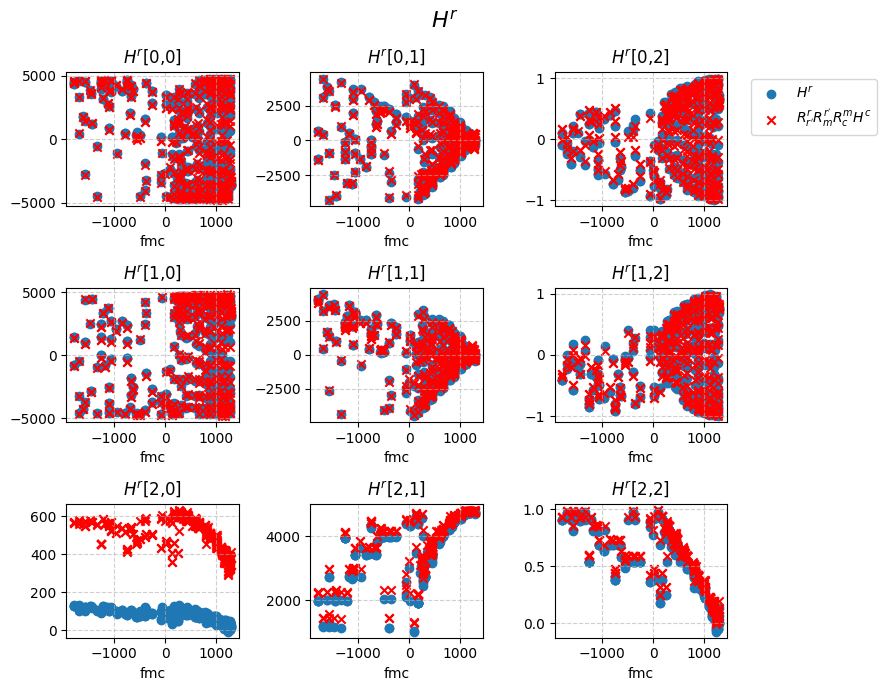

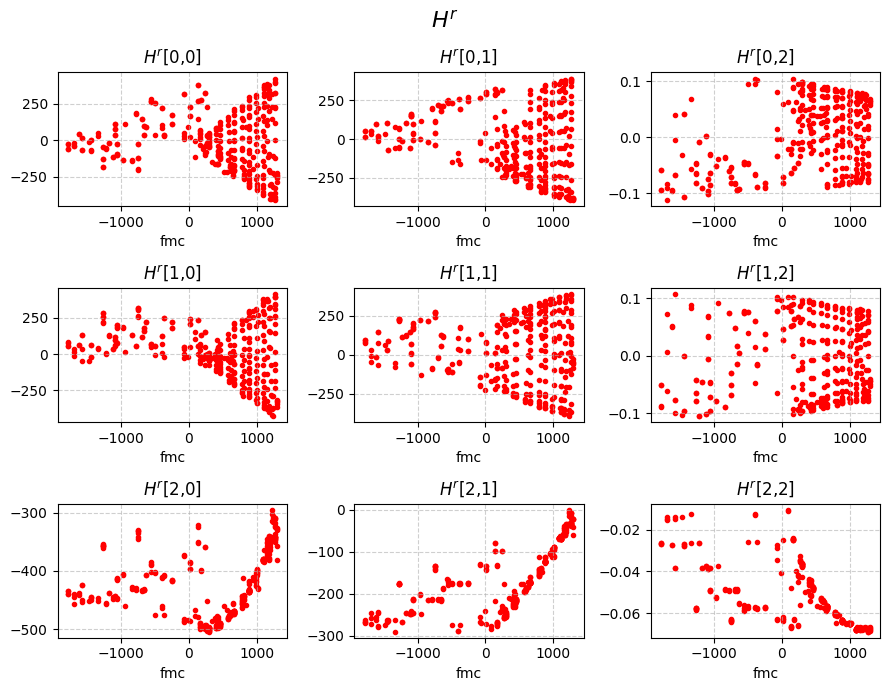

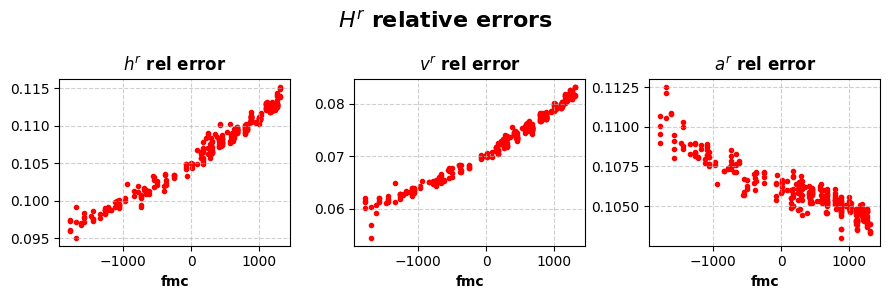

In [18]:
with open("Fits.json", "r") as file:
  fits = json.load(file)

f_str = "034"
cam = "ZR"
fit = fits[f"{cam}{f_str}"]
q_rrp, q_mc_0, q_mc_1 = fit["q_rrp"], fit["q_mc_0"], fit["q_mc_1"]
print(f"q_rrp:{list(q_rrp)}")
print(f"q_mc_0:{list(q_mc_0)}")
print(f"q_mc_1:{list(q_mc_1)}")

zl, zr = get_zl_zr(f_str, data_all)
parse_cahvor(zl)
parse_cahvor(zr)

if cam == "ZL":
  plot_qmc_hr(zl, q_rrp, q_mc_0, q_mc_1)
  plot_qmc_hr_err(zl, q_rrp, q_mc_0, q_mc_1)
  plot_qmc_hr_rel_err(zl, q_rrp, q_mc_0, q_mc_1)
else:
  plot_qmc_hr(zr, q_rrp, q_mc_0, q_mc_1)
  plot_qmc_hr_err(zr, q_rrp, q_mc_0, q_mc_1)
  plot_qmc_hr_rel_err(zr, q_rrp, q_mc_0, q_mc_1)

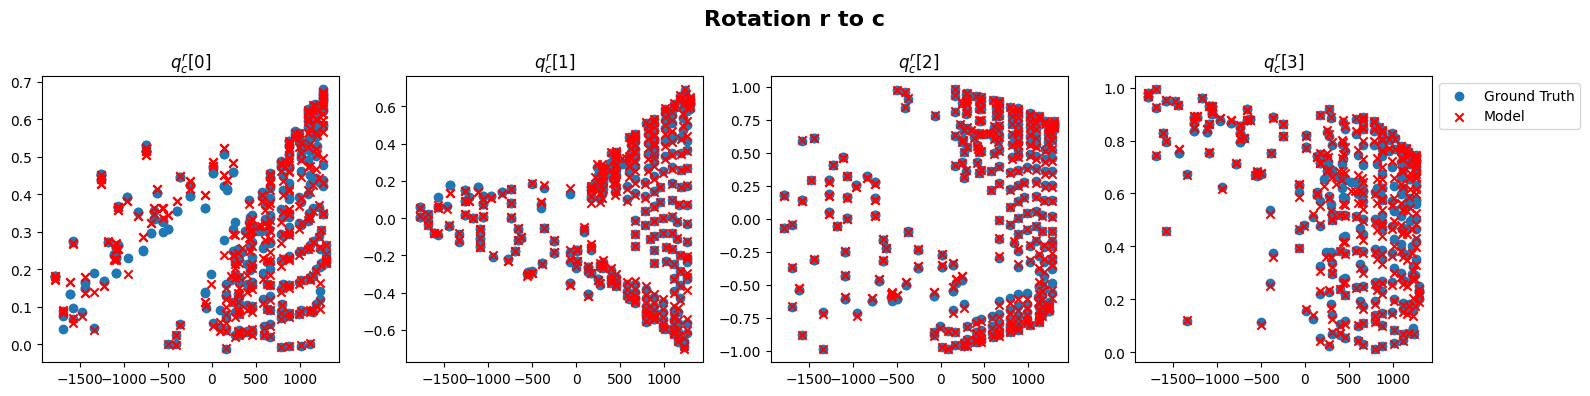

In [19]:
plot_qrc(zl if cam=="ZL" else zr, q_rrp, q_mc_0, q_mc_1)

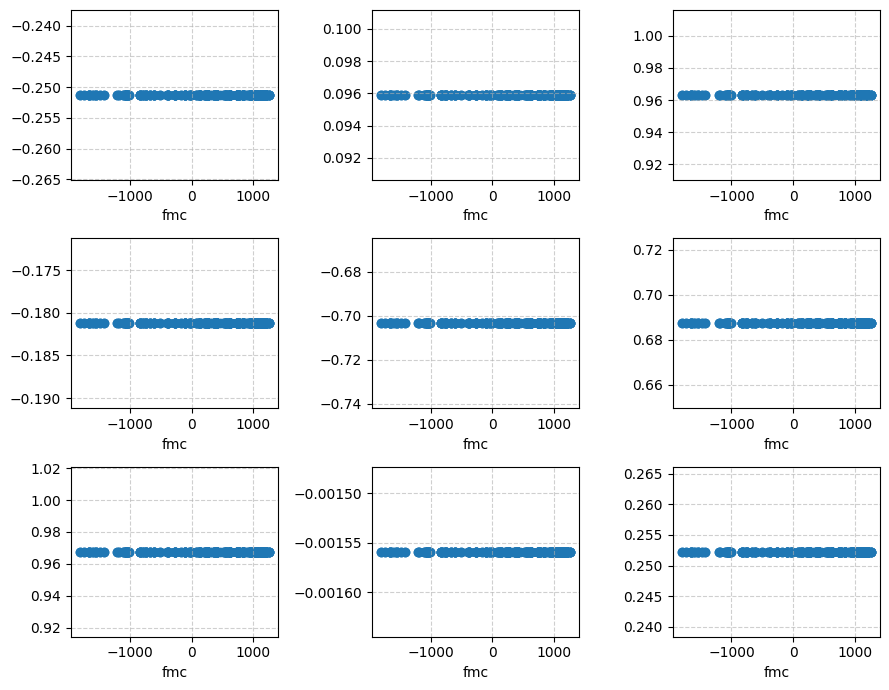

In [70]:
# here we plot the R_rpm matrix
fig, ax = plt.subplots(3, 3, figsize=(9,7))

for i in range(3):
  for j in range(3):
    ax[i,j].scatter(data["fmc"], [get_R_rpm(i, data)[i][j] for k in range(data.shape[0])])
    ax[i,j].set_xlabel("fmc")
    ax[i,j].grid(linestyle="--", alpha=0.6)

fig.tight_layout()